# **Exercise 1**

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Closing_Prices_5yrs.csv")
df.tail()

,Date,ASIANPAINT.csv,AXISBANK.csv,BAJAJFINSV.csv,BAJFINANCE.csv,BHARTIARTL.csv,HCLTECH.csv,HDFCBANK.csv,HINDUNILVR.csv,ICICIBANK.csv,...,RELIANCE.csv,SBIN.csv,SUNPHARMA.csv,TATAMOTORS.csv,TATASTEEL.csv,TCS.csv,TECHM.csv,TITAN.csv,ULTRACEMCO.csv,WIPRO.csv
1229,24-01-2024,2999.550049,1058.750000,1620.650024,7058.799805,1190.449951,1575.199951,1455.849976,2444.100098,999.200012,...,2688.699951,618.299988,1382.250000,810.900024,135.149994,3848.000000,1407.750000,3765.050049,9993.500000,478.000000
1230,25-01-2024,2949.550049,1043.099976,1630.199951,7085.149902,1159.849976,1551.000000,1435.300049,2430.100098,1009.900024,...,2710.350098,612.900024,1374.849976,811.450012,133.649994,3808.199951,1321.599976,3770.199951,9984.049805,469.950012
1231,29-01-2024,2976.449951,1061.500000,1637.000000,7187.500000,1162.050049,1574.849976,1455.650024,2444.399902,1017.349976,...,2896.149902,622.900024,1399.250000,840.849976,135.000000,3801.350098,1314.599976,3866.050049,10275.400390,472.950012
1232,30-01-2024,2954.850098,1053.849976,1590.949951,6815.600098,1158.300049,1558.900024,1444.199951,2458.949951,1016.299988,...,2814.850098,626.599976,1371.599976,859.250000,134.699997,3799.100098,1317.699951,3735.850098,9958.500000,472.399994
1233,31-01-2024,2958.000000,1067.449951,1627.150024,6863.799805,1170.699951,1575.800049,1462.250000,2480.399902,1027.900024,...,2853.199951,640.650024,1418.500000,884.200012,135.899994,3814.750000,1333.449951,3697.399902,10167.950200,477.799988


In [58]:
df.shape

(1234, 31)

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df.isnull().sum()

Date               0
ASIANPAINT.csv    21
AXISBANK.csv      21
BAJAJFINSV.csv    17
BAJFINANCE.csv    21
BHARTIARTL.csv    21
HCLTECH.csv       21
HDFCBANK.csv      21
HINDUNILVR.csv    21
ICICIBANK.csv     21
INDUSINDBK.csv    21
INFY.csv          21
ITC.csv           21
JSWSTEEL.csv      21
KOTAKBANK.csv     21
LT.csv            21
M&M.csv           21
MARUTI.csv        21
NESTLEIND.csv      2
NTPC.csv          21
POWERGRID.csv      2
RELIANCE.csv      21
SBIN.csv          21
SUNPHARMA.csv     21
TATAMOTORS.csv    21
TATASTEEL.csv     17
TCS.csv           21
TECHM.csv         21
TITAN.csv         21
ULTRACEMCO.csv    21
WIPRO.csv         21
dtype: int64

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1234 entries, 0 to 1233
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1234 non-null   object 
 1   ASIANPAINT.csv  1213 non-null   float64
 2   AXISBANK.csv    1213 non-null   float64
 3   BAJAJFINSV.csv  1217 non-null   float64
 4   BAJFINANCE.csv  1213 non-null   float64
 5   BHARTIARTL.csv  1213 non-null   float64
 6   HCLTECH.csv     1213 non-null   float64
 7   HDFCBANK.csv    1213 non-null   float64
 8   HINDUNILVR.csv  1213 non-null   float64
 9   ICICIBANK.csv   1213 non-null   float64
 10  INDUSINDBK.csv  1213 non-null   float64
 11  INFY.csv        1213 non-null   float64
 12  ITC.csv         1213 non-null   float64
 13  JSWSTEEL.csv    1213 non-null   float64
 14  KOTAKBANK.csv   1213 non-null   float64
 15  LT.csv          1213 non-null   float64
 16  M&M.csv         1213 non-null   float64
 17  MARUTI.csv      1213 non-null   f

In [62]:
# Convert Date column (DD-MM-YYYY) to datetime
df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], dayfirst=True)

# Sort data by date
df = df.sort_values(by=df.columns[0]).reset_index(drop=True)

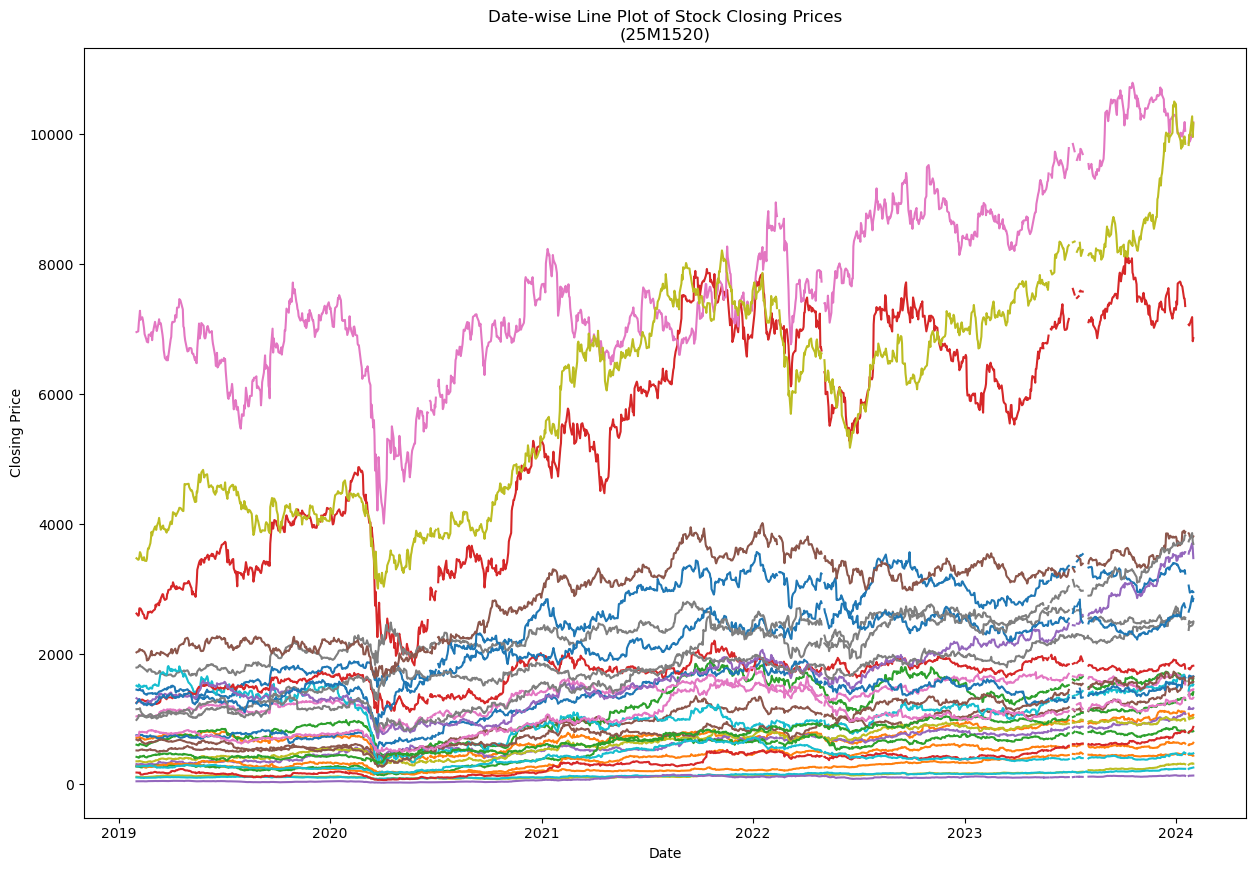

In [ ]:
df.columns = [col.split(".")[0] for col in df.columns]  # removing .csv from column names

dates = df.iloc[:, 0]
df = df.iloc[:,1:]       # remove Date column

# Line plot (date-wise)
plt.figure(figsize=(15,10))
for stock in df.columns:
    plt.plot(dates, df[stock])

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Date-wise Line Plot of Stock Closing Prices\n(25M1520)")
plt.show()

In [64]:
returns_5d = df.pct_change(periods=5).dropna()

/tmp/ipykernel_81063/1623673990.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_5d = df.pct_change(periods=5).dropna()


In [65]:
returns_5d

,ASIANPAINT,AXISBANK,BAJAJFINSV,BAJFINANCE,BHARTIARTL,HCLTECH,HDFCBANK,HINDUNILVR,ICICIBANK,INDUSINDBK,...,RELIANCE,SBIN,SUNPHARMA,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,ULTRACEMCO,WIPRO
5,-0.005868,0.002582,0.013671,0.029229,0.007388,0.020977,0.015060,0.011775,0.001128,-0.013277,...,0.024092,0.002638,0.018074,-0.167538,-0.008133,0.015758,0.074480,0.063149,0.022067,0.002827
6,-0.007215,-0.012305,0.014834,0.022532,0.021037,0.035311,0.014404,0.001220,-0.014946,0.004198,...,-0.029199,-0.013399,0.033426,-0.154465,0.009668,0.008988,0.079197,0.029395,-0.001520,0.003773
7,-0.001207,-0.030159,0.015483,0.008243,0.011856,0.013344,0.006998,-0.014468,-0.022421,-0.025842,...,-0.026041,-0.031986,0.067066,-0.137283,0.049919,0.003082,0.073800,0.000000,-0.002124,0.015602
8,-0.045298,-0.040268,-0.027570,-0.037117,-0.023516,0.007117,-0.006241,-0.025348,-0.044023,-0.003865,...,-0.064397,-0.073387,0.060785,-0.104097,-0.003922,-0.015978,-0.006967,-0.013596,-0.003593,0.008870
9,-0.052172,-0.058682,-0.034685,-0.051970,-0.021225,-0.003016,-0.007534,-0.034760,-0.046690,-0.002708,...,-0.036196,-0.085709,-0.024654,-0.119191,-0.041325,-0.023559,-0.004538,-0.017349,-0.036588,0.005085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1229,-0.074870,-0.022798,0.022524,-0.040552,0.097037,-0.000539,-0.052736,-0.046688,0.019228,-0.092757,...,-0.012524,-0.012537,0.063883,0.006641,0.026586,-0.009307,0.061091,-0.016958,0.014491,-0.008916
1230,-0.090291,-0.037242,0.028550,-0.036971,0.068838,-0.015894,-0.066107,-0.052149,0.030142,-0.079093,...,-0.004572,-0.021161,0.058187,0.007324,0.015192,-0.019554,-0.003844,-0.015614,0.013532,-0.025606
1231,-0.059752,-0.048835,0.022869,-0.018148,0.032933,0.004433,-0.010233,-0.046925,0.018266,-0.021495,...,0.058902,-0.007647,0.047931,0.021317,0.005961,-0.035741,-0.054040,0.014818,0.017921,-0.024845
1232,-0.066575,-0.055690,-0.005905,-0.068952,0.029600,-0.005740,-0.018019,-0.041252,0.017216,-0.027837,...,0.029177,-0.001752,0.027223,0.043666,0.003726,-0.036312,-0.051810,-0.019359,-0.013473,-0.025979


# Question 1

In [66]:
avg_returns = returns_5d.mean()
print(f"Average 5-day return for each stock:\n\n{avg_returns}")

Average 5-day return for each stock:

ASIANPAINT    0.003590
AXISBANK      0.002926
BAJAJFINSV    0.005422
BAJFINANCE    0.005508
BHARTIARTL    0.006185
HCLTECH       0.005160
HDFCBANK      0.002014
HINDUNILVR    0.001712
ICICIBANK     0.005228
INDUSINDBK    0.002843
INFY          0.004029
ITC           0.002632
JSWSTEEL      0.005742
KOTAKBANK     0.002205
LT            0.004958
M&M           0.004741
MARUTI        0.002319
NESTLEIND     0.003577
NTPC          0.004953
POWERGRID     0.004230
RELIANCE      0.004047
SBIN          0.004405
SUNPHARMA     0.005605
TATAMOTORS    0.008726
TATASTEEL     0.005697
TCS           0.003055
TECHM         0.003137
TITAN         0.006179
ULTRACEMCO    0.005059
WIPRO         0.003012
dtype: float64


# Question 2

In [67]:
std_returns = returns_5d.std()
print(f"Standard deviation of 5-day returns:\n\n{std_returns}")

Standard deviation of 5-day returns:

ASIANPAINT    0.037317
AXISBANK      0.051386
BAJAJFINSV    0.053321
BAJFINANCE    0.055369
BHARTIARTL    0.039362
HCLTECH       0.037150
HDFCBANK      0.037796
HINDUNILVR    0.031635
ICICIBANK     0.043456
INDUSINDBK    0.072456
INFY          0.040423
ITC           0.036736
JSWSTEEL      0.051106
KOTAKBANK     0.039618
LT            0.040719
M&M           0.049250
MARUTI        0.042996
NESTLEIND     0.030274
NTPC          0.040443
POWERGRID     0.036321
RELIANCE      0.042183
SBIN          0.049683
SUNPHARMA     0.038745
TATAMOTORS    0.070713
TATASTEEL     0.053982
TCS           0.032701
TECHM         0.042043
TITAN         0.042740
ULTRACEMCO    0.038552
WIPRO         0.041207
dtype: float64


# Question 3

In [68]:
cov_matrix = returns_5d.cov()   # covariance matrix
cov_matrix

,ASIANPAINT,AXISBANK,BAJAJFINSV,BAJFINANCE,BHARTIARTL,HCLTECH,HDFCBANK,HINDUNILVR,ICICIBANK,INDUSINDBK,...,RELIANCE,SBIN,SUNPHARMA,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,ULTRACEMCO,WIPRO
ASIANPAINT,0.001393,0.000639,0.000686,0.000811,0.000206,0.000327,0.000532,0.000607,0.000603,0.000937,...,0.000426,0.000479,0.000304,0.000454,0.000368,0.000358,0.000369,0.000752,0.000599,0.000333
AXISBANK,0.000639,0.002641,0.001568,0.001667,0.000649,0.000375,0.001206,0.000480,0.001729,0.002628,...,0.000741,0.001724,0.000645,0.001690,0.001008,0.000322,0.000644,0.001098,0.000928,0.000493
BAJAJFINSV,0.000686,0.001568,0.002843,0.002510,0.000583,0.000444,0.001151,0.000403,0.001422,0.002183,...,0.000766,0.001467,0.000471,0.001621,0.001312,0.000432,0.000789,0.001168,0.000893,0.000568
BAJFINANCE,0.000811,0.001667,0.002510,0.003066,0.000576,0.000439,0.001245,0.000558,0.001508,0.002365,...,0.000840,0.001586,0.000404,0.001604,0.001216,0.000445,0.000717,0.001238,0.000879,0.000532
BHARTIARTL,0.000206,0.000649,0.000583,0.000576,0.001549,0.000357,0.000390,0.000239,0.000509,0.000840,...,0.000400,0.000528,0.000410,0.000778,0.000556,0.000290,0.000377,0.000378,0.000450,0.000283
HCLTECH,0.000327,0.000375,0.000444,0.000439,0.000357,0.001380,0.000425,0.000260,0.000367,0.000795,...,0.000592,0.000303,0.000434,0.000694,0.000563,0.000810,0.000942,0.000483,0.000516,0.000940
HDFCBANK,0.000532,0.001206,0.001151,0.001245,0.000390,0.000425,0.001429,0.000386,0.001158,0.001712,...,0.000667,0.001118,0.000336,0.001098,0.000679,0.000392,0.000481,0.000807,0.000638,0.000513
HINDUNILVR,0.000607,0.000480,0.000403,0.000558,0.000239,0.000260,0.000386,0.001001,0.000338,0.000560,...,0.000367,0.000283,0.000257,0.000304,0.000214,0.000277,0.000219,0.000546,0.000414,0.000315
ICICIBANK,0.000603,0.001729,0.001422,0.001508,0.000509,0.000367,0.001158,0.000338,0.001888,0.002186,...,0.000726,0.001553,0.000487,0.001383,0.000939,0.000341,0.000528,0.000997,0.000869,0.000471
INDUSINDBK,0.000937,0.002628,0.002183,0.002365,0.000840,0.000795,0.001712,0.000560,0.002186,0.005250,...,0.001106,0.002367,0.000878,0.002444,0.001545,0.000625,0.000894,0.001373,0.001207,0.000754


In [69]:
var_returns = returns_5d.var()
var_returns

ASIANPAINT    0.001393
AXISBANK      0.002641
BAJAJFINSV    0.002843
BAJFINANCE    0.003066
BHARTIARTL    0.001549
HCLTECH       0.001380
HDFCBANK      0.001429
HINDUNILVR    0.001001
ICICIBANK     0.001888
INDUSINDBK    0.005250
INFY          0.001634
ITC           0.001350
JSWSTEEL      0.002612
KOTAKBANK     0.001570
LT            0.001658
M&M           0.002426
MARUTI        0.001849
NESTLEIND     0.000916
NTPC          0.001636
POWERGRID     0.001319
RELIANCE      0.001779
SBIN          0.002468
SUNPHARMA     0.001501
TATAMOTORS    0.005000
TATASTEEL     0.002914
TCS           0.001069
TECHM         0.001768
TITAN         0.001827
ULTRACEMCO    0.001486
WIPRO         0.001698
dtype: float64

#### Yes!! the standard deviation (square root of var) computed in the step above is consistent with the covariances (as diagonal elements of covariance matrix represent variances and it is same as variances calculated separately)

# Question 4

In [70]:
best_avg_return = avg_returns.max() # maximum of avg_returns
best_stock = avg_returns.idxmax()   # index of maximum of avg_returns
best_std = std_returns[best_stock]  # standard deviation of maximum of avg_returns

print(f"Stock with highest average 5-day return: {best_stock}")
print("Average return:", best_avg_return)
print("Standard deviation:", best_std)

Stock with highest average 5-day return: TATAMOTORS
Average return: 0.008726016557537426
Standard deviation: 0.07071329998280448


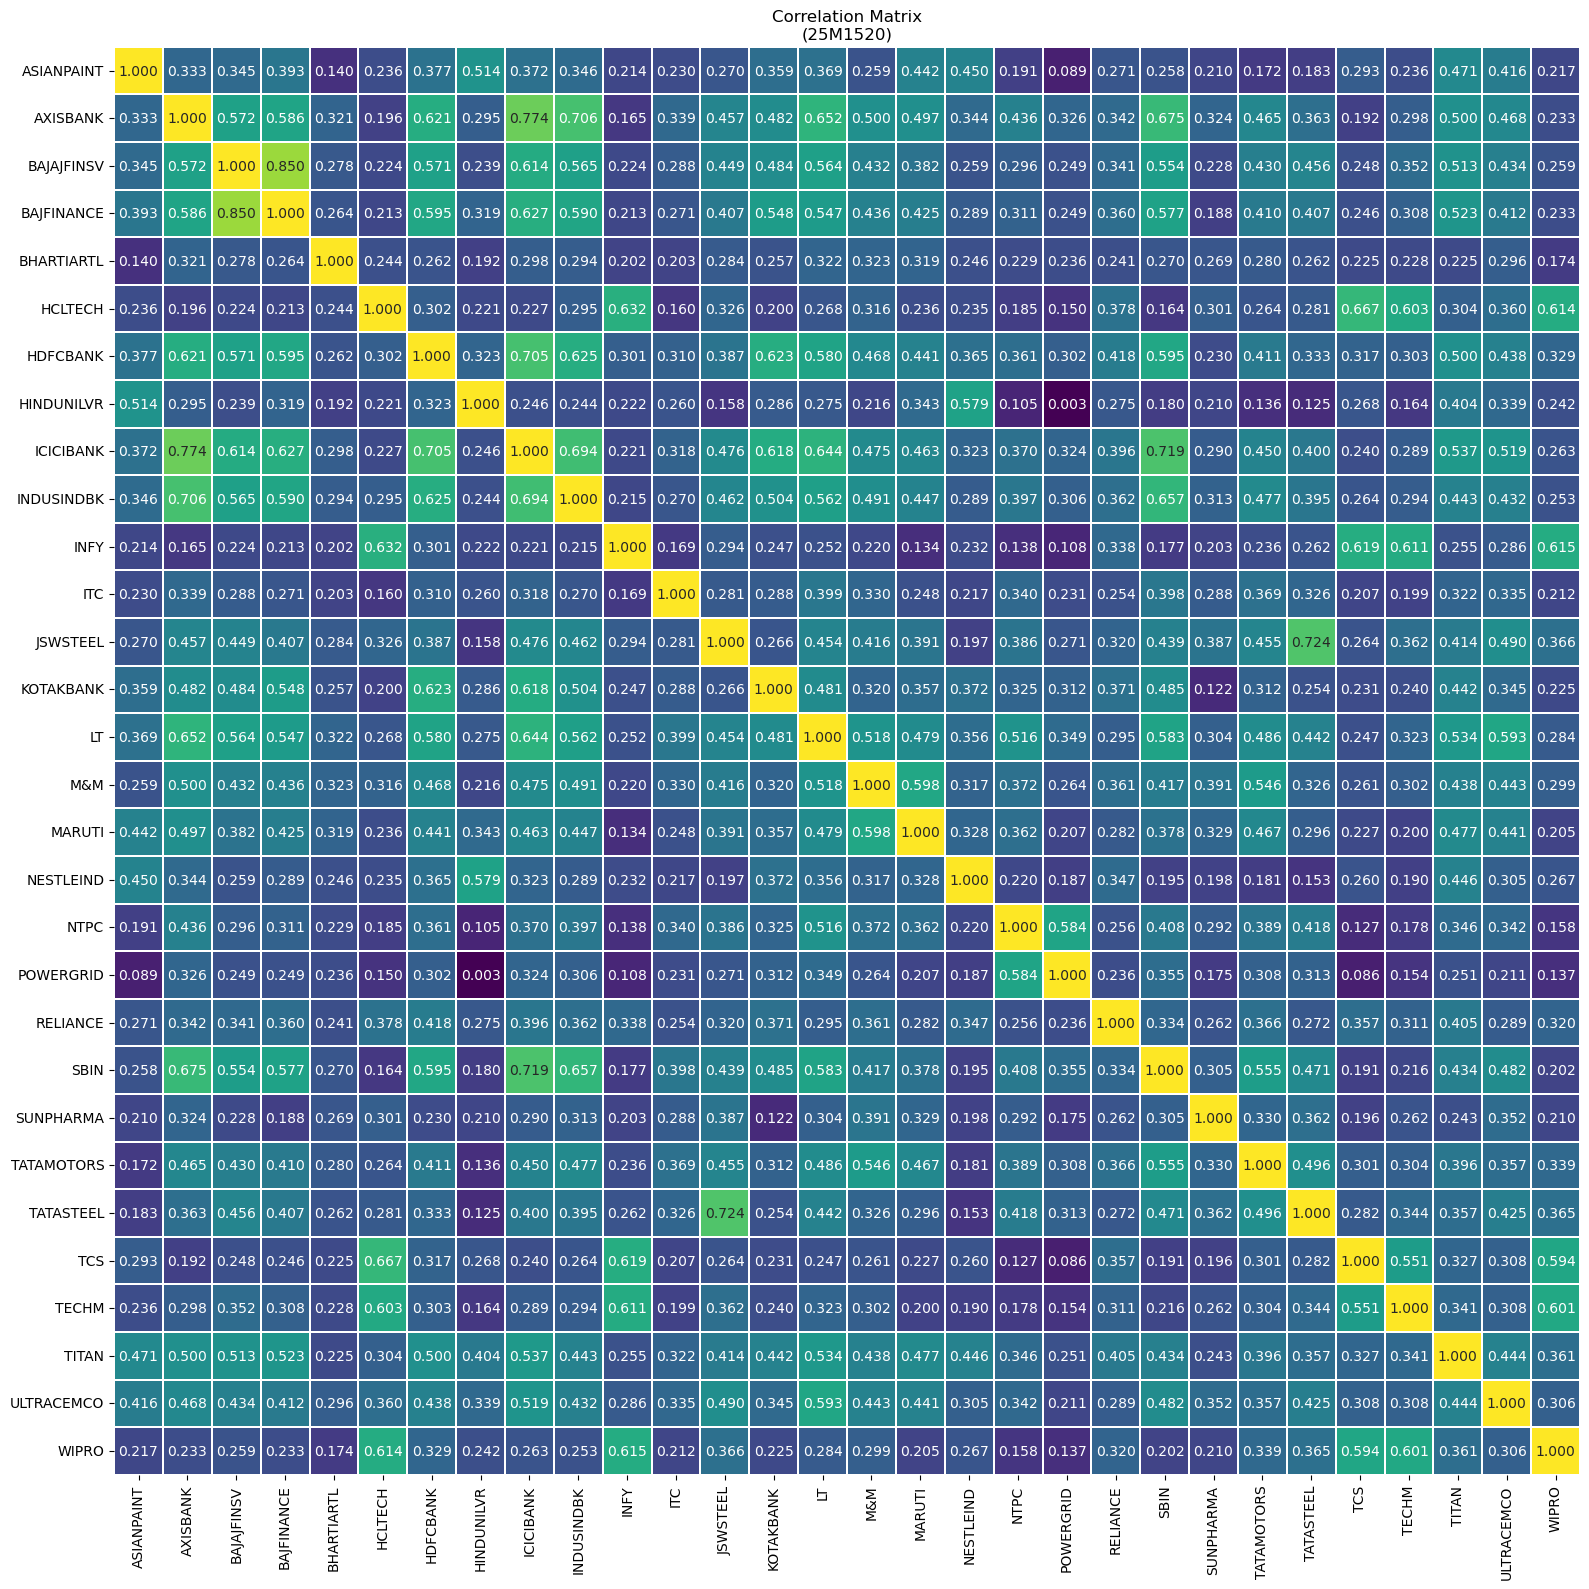

In [71]:
corr_matrix = returns_5d.corr()
plt.figure(figsize=(16, 16))
sns.heatmap(corr_matrix,annot=True,fmt=".3f",linewidths=0.05,cmap="viridis",cbar=False)
plt.title("Correlation Matrix\n(25M1520)")
plt.tight_layout()
plt.show()

In [72]:
pairs = []      # this list will contain tuples in the form of (stock1, stock2, corr) 
cols = corr_matrix.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        pairs.append((cols[i], cols[j], corr_matrix.iloc[i, j]))

pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True) # sorted in descending order w.r.t. absolute value of corr
top3_pairs = pairs_sorted[:3]

print("Top 3 highly correlated stock pairs:\n")
for s1, s2, corr in top3_pairs:
    print(f"corr({s1},{s2}) = {corr:.3f}")


Top 3 highly correlated stock pairs:

corr(BAJAJFINSV,BAJFINANCE) = 0.850
corr(AXISBANK,ICICIBANK) = 0.774
corr(JSWSTEEL,TATASTEEL) = 0.724


# Question 5

In [ ]:
from pyomo.environ import *

mu = avg_returns.values  # expected returns
S = cov_matrix.values    # covariance matrix

n = len(mu)
B = 1e7                        # Rs. 1 crore budget
R_target = 0.00025 * B         # target return in Rs.

# Minimum risk for target return
def min_risk_portfolio(R_target):
    model = ConcreteModel()
    model.N = RangeSet(0, n-1)
    model.x = Var(model.N, domain=NonNegativeReals)

    model.obj = Objective(
        expr=sum(model.x[i]*S[i,j]*model.x[j] for i in model.N for j in model.N),
        sense=minimize
    )

    model.budget = Constraint(expr=sum(model.x[i] for i in model.N) == B)
    model.ret = Constraint(expr=sum(mu[i]*model.x[i] for i in model.N) >= R_target)

    SolverFactory("ipopt").solve(model)

    x = np.array([value(model.x[i]) for i in model.N])
    risk = x@S@x
    ret = mu@x

    return x, risk, ret

# Question 6

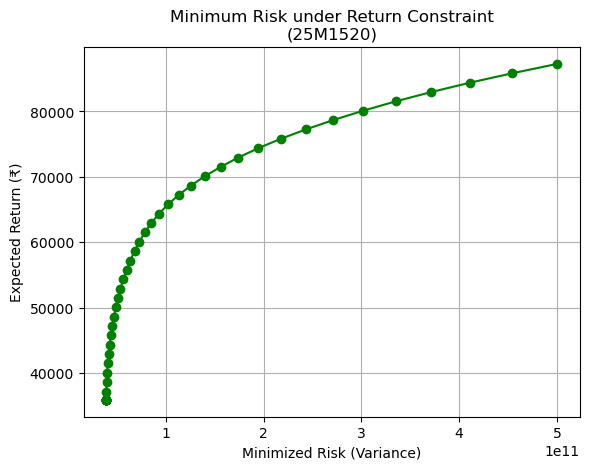

In [74]:
targets = np.linspace(mu.min() * B, mu.max() * B, 50)
risks, rets = [], []

for R in targets:
    x, risk, ret = min_risk_portfolio(R)
    risks.append(risk)
    rets.append(ret)

plt.figure()
plt.plot(risks, rets, marker='o',color='g')
plt.xlabel("Minimized Risk (Variance)")
plt.ylabel("Expected Return (₹)")
plt.title("Minimum Risk under Return Constraint\n(25M1520)")
plt.grid(True)
plt.show()

# Question 7

model.name="unknown";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.6\x3a Maximum Number of Iterations
      Exceeded.
model.name="unknown";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.6\x3a Maximum Number of Iterations
      Exceeded.


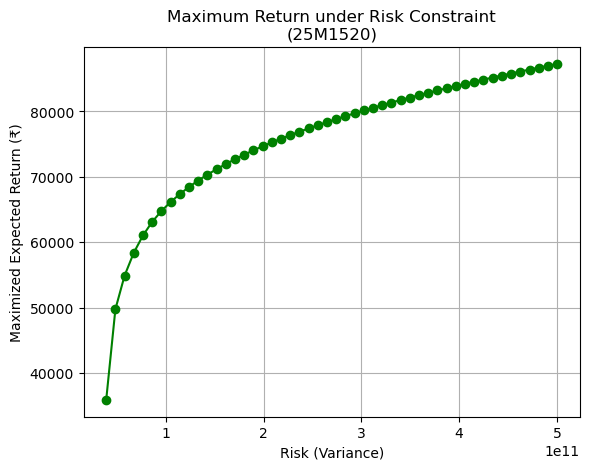

In [75]:
# Maximize return under risk limit
def max_return_portfolio(risk_limit):
    model = ConcreteModel()
    model.N = RangeSet(0, n-1)
    model.x = Var(model.N, domain=NonNegativeReals)

    model.obj = Objective(
        expr=sum(mu[i]*model.x[i] for i in model.N),
        sense=maximize
    )

    model.budget = Constraint(expr=sum(model.x[i] for i in model.N) == B)
    model.risk = Constraint(expr=sum(model.x[i]*S[i,j]*model.x[j] for i in model.N for j in model.N) <= risk_limit)

    SolverFactory("ipopt").solve(model)

    x = np.array([value(model.x[i]) for i in model.N])
    risk = x@S@x
    ret = mu@x

    return x, risk, ret

risk_limits = np.linspace(min(risks), max(risks), 50)

risks2, rets2 = [], []

for rl in risk_limits:
    x, risk, ret = max_return_portfolio(rl)
    risks2.append(risk)
    rets2.append(ret)

plt.figure()
plt.plot(risks2, rets2, marker='o',color='g')
plt.xlabel("Risk (Variance)")
plt.ylabel("Maximized Expected Return (₹)")
plt.title("Maximum Return under Risk Constraint\n(25M1520)")
plt.grid(True)
plt.show()

# Question 8

In [76]:
# Equal-weight portfolio
x_equal = np.full(n,B/n)

equal_return = mu@x_equal
equal_risk = x_equal@S@x_equal

print("Equal-weight portfolio:")
print("Expected return (₹):", equal_return)
print("Risk (variance):", equal_risk)


Equal-weight portfolio:
Expected return (₹): 42965.03238552611
Risk (variance): 74272466839.27237


### In Q8, an equal-investment strategy is considered, where the total budget of ₹1 crore is divided equally among all 30 stocks: 
###                             $x_i = 1,00,00,000/30 = 333333.333  ₹ $

### Observation:
- The equal-weight portfolio is simple and well diversified since capital is
  distributed uniformly across all stocks.
- However, it ignores differences in expected returns, variances, and
  correlations among the stocks.
- On the risk–return plane, this portfolio lies inside the efficient frontier.

### Conclusion:
- The equal-weight portfolio is not optimal in the mean–variance sense.
- There exist portfolios that can achieve the same expected return with lower
  risk or a higher expected return for the same risk.
- Hence, the optimized portfolios obtained in Q5–Q7 strictly dominate the
  equal-weight strategy.

